In [73]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter


import cmath

from qutip import *
from joblib import Parallel, delayed

from numba import njit, prange
from numba import set_num_threads, get_num_threads


# --- Labels ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}

In [74]:
def gate_U(vx, d):
    UL = 0  #in meV
    UR = 0
    
    vUG = (UR+UL)/2. + (UR-UL)/np.pi*np.arctan(vx/d)
    
    return vUG

def donor_U(vx, d, E0):
    vDonors = np.zeros(len(vx))
    #E0 = 4377 #in meV
    vDonors = - E0 * (1-vx**2/d**2)**.5
    return vDonors
    
def kernel(vx, vt, d):
    l_cut = 1  #in nm
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mK = np.log( np.abs( (np.sqrt( (d**2 - mx**2.)*(d**2.-mt**2) ) + d**2 - mx*mt )/d**2 ) ) - np.log( np.abs((mx-mt + 1e-12)/d) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)

def kernel_1D_image(vx, vt, d, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mdedge = dedge * np.ones(shape=(len(vx), len(vt)))
    l_cut = 2.  #in nm
        
    #mK = np.log( np.abs( (np.sqrt( (md**2 - mx**2.)*(md**2.-mt**2) ) + d**2 - mx*mt )/(mx-mt + 1e-7)/md ) ) 
    #mK += np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )
    
    #mK = - ( np.log( np.abs( mx - mt + 1e-7 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )  ) 
    #mK = - ( np.log( np.abs( mx - mt + 1e-10 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.sqrt( (mx - mt)**2 + (2*mdedge)**2 + 1e-10 ) )  ) 
    mK = - np.log( np.abs( mx - mt + 1e-12 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) + np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-12 ) ) + 0*np.log( np.sqrt( (mx - mt)**2 + (2*3400)**2 + 1e-10 ) )   
    
    return mK - np.amin(mK)

def kernel_1D_0(vx, vt, d):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    l_cut = 1  #in nm
    mK = - np.log( np.abs( mx - mt + 1e-12 )/(d) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)

def kernel_3D(vx, vt, d, sides, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    mK = np.zeros(shape=(len(vx), len(vt)))
    
    l_cut = .1  #in nm
    if sides == 2:
        for m in range(-100,100):
            mK += (1./np.abs( mx - mt - 4*d*m + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    elif sides == 1:
        #m = 1
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
        
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d + 2*dedge + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm   LEFT
        mK = (1./np.abs( mx - mt + 1e-7 )* (1-np.exp(-np.abs(mx-mt)/l_cut )) - 1./np.abs( mx + mt - 2*d - 2*dedge + 1e-7 ) )   #smooth UV cutoff at l_cut in nm      RIGHT
    elif sides == 0:
        m = 1
        mK = (1./np.abs( mx - mt + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    return mK - np.amin(mK)

def int_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.sum(mK, axis=1)*dx *n0*U0
    return vDonors

def int_nonhomo_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.dot(mK, n0)*dx *U0
    return vDonors

def dos_B( B, vE, gam0 ):
    lB = 25/B**.5   #in nm and B in T
    omB = 1.76 * B  #in meV and B in T
    EZ = omB/3.
    Gam = gam0 * omB * (10/B)**.5
    vD = np.zeros( len(vE) )
    for n in range(150):
        epsn = (.5+n)*omB
        vD += 1./(2*np.pi*lB**2.) * ( np.exp( - (epsn - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 + np.exp( - (epsn+EZ - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 )
    
    return vD

@njit
def number_e(T, vx, vU, vD, vE, mu):    #T in meV
    num_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        F = 1./( np.exp( (E + vU - mu)/T ) + 1. )
        num_e += dE*vD[ne] * F
    
    return num_e

@njit
def dmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        dF = 1./( np.exp( (E + vU - mu)/T ) + 1. )**2. * np.exp( (E + vU - mu)/T )/T
        dnum_e += dE*vD[ne] * dF
    
    return dnum_e

@njit
def ddddmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    if T > 1.:
        for ne, E in enumerate(vE):
            dF = 1./( np.exp( (E + vU - mu)/T ) + 1. )**2. * np.exp( (E + vU - mu)/T )/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

In [75]:
T = .5 #in meV 0.01 => 0.116 K
B = 6   #in T
omB = 1.76 * B
d = 1000   #in nm
lB = 25/B**.5   #in nm
dedge = 10000

gam0 = 0.02  #adimensional width of the LLs

margin0 = .9999
margin = .9
Nx = 2500
vx = np.linspace(-margin0*d, margin0*d, Nx)
vt = np.linspace(-margin0*d, margin0*d, Nx)

#eff_eps = 1.44/10. * 10e3
kappa0 = 1.44/13. * 10e3  #in meV * nm

mK = kernel(vx, vt, d)
#mK = kernel_3D(vx, vt, d, 1, dedge)
#mK = kernel_1D_image(vx, vt, d, dedge)
#mK = kernel_1D_0(vx, vt, d)


vE = np.linspace(.0001, 7, 1500) * omB
vD = dos_B( B, vE, gam0 )

targ_num_e = 4 * 1e-3     #in nm^-2 ---> 10^-3 nm^-2 = 10^11 cm^-2
num_D = targ_num_e * np.pi

filling0 = targ_num_e * 2*np.pi*lB**2.
print(filling0)

ED = np.pi/2 * kappa0 * num_D * 2*d #in meV
print(ED)
vUG = gate_U(vx, d)
vUD = donor_U(vx, d, ED)

2.617993877991495
43729.93950021131


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_57641/3744318827.py:5: RuntimeWarning: overflow encountered in exp
  f = (1-1/( np.exp( (vx-low_x)/xr) + 1 ))*1/( np.exp( (vx-high_x)/xr) + 1 )


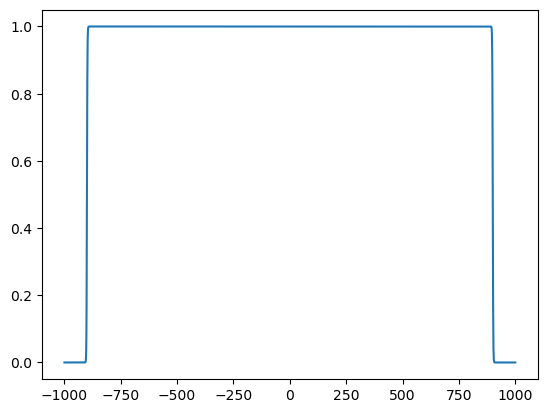

In [76]:
def step_fun(vx):
    low_x = np.amin(vx)*margin
    high_x = np.amax(vx)*margin
    xr = 1
    f = (1-1/( np.exp( (vx-low_x)/xr) + 1 ))*1/( np.exp( (vx-high_x)/xr) + 1 )
    return f

sf = step_fun(vx)
plt.plot(vx, sf)

(0.0, 2.0)

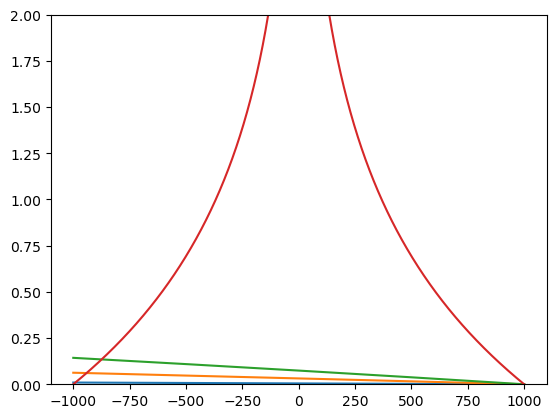

In [77]:
img1 = np.log( np.abs( vx - 2*6e3 - 2*100e3 + 1e-7 ) )
img2 = np.log( np.abs( vx - 2*6e3 - 2*10e3 + 1e-7 ) )
img3 = np.log( np.abs( vx - 2*6e3 - 2*1e3 + 1e-7 ) )
CC = -np.log( np.abs( vx + 1e-7 ) )
plt.plot(vx, img1-np.amin(img1) )
plt.plot(vx, img2-np.amin(img2) )
plt.plot(vx, img3-np.amin(img3) )
plt.plot(vx, CC-np.amin(CC))
plt.ylim(0,2)

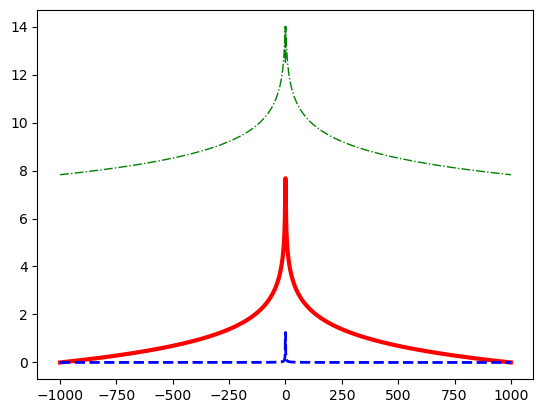

In [78]:
mK_3D = kernel_3D(vx, vt, d, 1, dedge)
mK_1D = kernel_1D_image(vx, vt, d, dedge)
mK_bare = kernel(vx, vt, d)

plt.plot(vx, np.fliplr(mK_1D).diagonal(), color='red', linewidth=3 )
plt.plot(vx, np.fliplr(mK_3D).diagonal(), color='blue', linestyle='--', linewidth=2 )
plt.plot(vx, np.fliplr(mK_bare).diagonal(), color='green', linestyle='-.', linewidth=1 )
#plt.ylim(0,.2)
#plt.yscale('log')

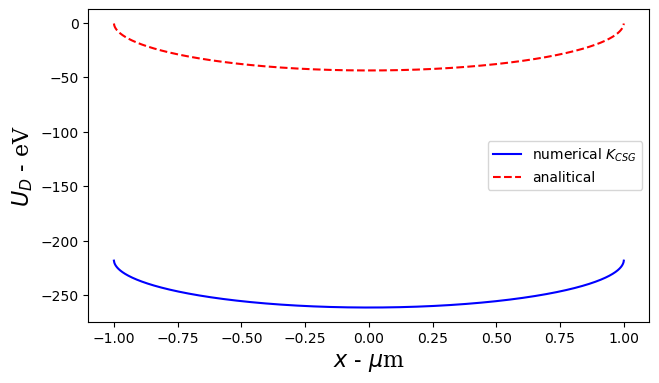

In [79]:
dx = np.abs(vx[1]-vx[0])
vUD_int = int_nonhomo_donor_U(vx, d, mK, num_D*np.ones(len(vx)), kappa0)


plt.plot(vx*1e-3, vUD_int*1e-3, color='blue', label=r'numerical $K_{CSG}$')
plt.plot(vx*1e-3, vUD*1e-3, color='red', linestyle='--', label=r'analitical')
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U_D$ - eV", fontdict=font)
plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("U_donor.pdf")

In [80]:
vUD = vUD_int

(0.0, 0.0031615055335983827)

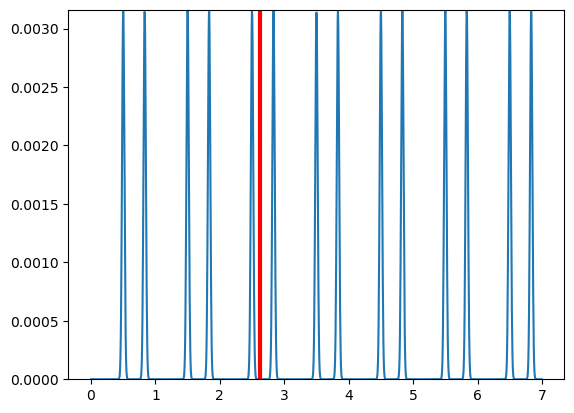

In [81]:
plt.plot(vE/omB, vD)
plt.vlines(filling0, ymin=0, ymax=np.amax(vD), color='red', linewidth=3)
plt.ylim(0,np.amax(vD))

In [82]:
vU_free = vUG + vUD

mu0 = omB*filling0 + np.amin(vUD)
D0 = 2.8 * 1e-4 #in meV^-1 nm^-2

arr_mu = mu0 + np.linspace(-.9999999, .0,1000)*mu0
avg_num_e = np.zeros(len(arr_mu))
for nmu, mu in enumerate(arr_mu):
    #num_e_free = number_e(T, vx, vU_free, vD, vE, mu)
    v = mu - vU_free
    thet = w = np.where(v > 0, 1, 0)
    num_e_free = D0 * np.multiply ( (mu - vU_free), thet )
    dx = np.abs(vx[0]-vx[1])
    avg_num_e[nmu] = 1/(2*d)*dx*np.sum(num_e_free)
nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
mu = arr_mu[nmui]
print(avg_num_e[nmui]/targ_num_e, targ_num_e)
print(avg_num_e)
print(mu, np.amin(vUD))


1.55117999897443 0.004
[7.05802784e+01 7.05070013e+01 7.04337242e+01 7.03604471e+01
 7.02871700e+01 7.02138929e+01 7.01406158e+01 7.00673387e+01
 6.99940616e+01 6.99207845e+01 6.98475074e+01 6.97742303e+01
 6.97009532e+01 6.96276761e+01 6.95543990e+01 6.94811219e+01
 6.94078448e+01 6.93345677e+01 6.92612906e+01 6.91880135e+01
 6.91147364e+01 6.90414592e+01 6.89681821e+01 6.88949050e+01
 6.88216279e+01 6.87483508e+01 6.86750737e+01 6.86017966e+01
 6.85285195e+01 6.84552424e+01 6.83819653e+01 6.83086882e+01
 6.82354111e+01 6.81621340e+01 6.80888569e+01 6.80155798e+01
 6.79423027e+01 6.78690256e+01 6.77957485e+01 6.77224714e+01
 6.76491943e+01 6.75759172e+01 6.75026401e+01 6.74293630e+01
 6.73560859e+01 6.72828088e+01 6.72095317e+01 6.71362546e+01
 6.70629774e+01 6.69897003e+01 6.69164232e+01 6.68431461e+01
 6.67698690e+01 6.66965919e+01 6.66233148e+01 6.65500377e+01
 6.64767606e+01 6.64034835e+01 6.63302064e+01 6.62569293e+01
 6.61836522e+01 6.61103751e+01 6.60370980e+01 6.59638209e+01
 

In [83]:
dx = np.abs(vx[0]-vx[1])
a0 = 10     #screening lenght in nm
vR = 1./(np.pi*a0) * mu * np.dot(mK, np.multiply(np.ones(len(vx)), sf ))*dx + vUD + vUG

matrix = np.eye(len(vx)) + 1./(np.pi*a0) * dx * np.multiply(mK, sf[np.newaxis,:])
M1 = scipy.linalg.inv(matrix)
vU = np.dot(M1, vR)

mu1 = mu
arr_mu = mu1 + np.linspace(-.9, .1,1000)*mu1
avg_num_e = np.zeros(len(arr_mu))
D0 = 2.8 * 1e-4 #in meV^-1 nm^-2
for nmu, mu1 in enumerate(arr_mu):
    v = mu1 - vU
    thet = w = np.where(v > 0, 1, 0)
    num_e_free = D0 * np.multiply ( (mu1 - vU), thet )
    dx = np.abs(vx[0]-vx[1])
    avg_num_e[nmu] = 1/(2*d)*dx*np.sum(num_e_free)
nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
mu1 = arr_mu[nmui]

nxR = np.argmin(np.abs(vx-.9*d))
print(vU[nxR], np.amin(vU), mu1, mu)

-256686.06253807526 -261321.58465093464 -261337.42502116557 -261102.19781592602


In [84]:
Umin = np.amin(vU)
UDmin = np.amin(vUD)

vU = vU - np.amin(vU)
vUD = vUD - np.amin(vUD)

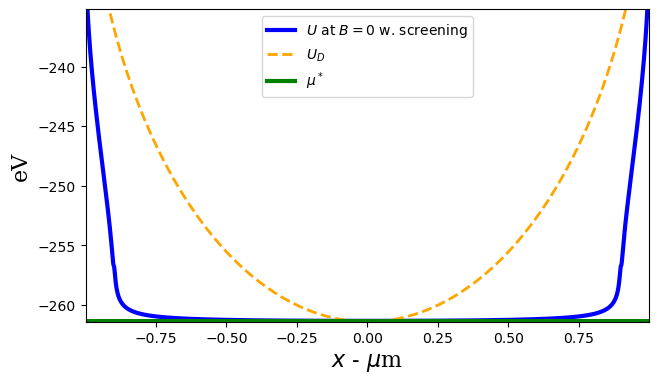

In [85]:
#norm = ED
plt.plot(vx*1e-3, (vU+Umin)*1e-3, color='blue', linewidth=3, label=r'$U$ at $B=0$ w. screening')
plt.plot(vx*1e-3, (vUD+UDmin)*1e-3, linestyle='--', color='orange', linewidth=2, label=r'$U_D$')
plt.plot(vx*1e-3, mu1*np.ones(len(vx))*1e-3, color='green', linewidth=3, label=r"$\mu^*$")
ymax = max(np.amax((vU+Umin)*1e-3), np.amax((vUD+UDmin)*1e-3) )
ymin = min( np.amin((vU+Umin)*1e-3), np.amin((vUD+UDmin)*1e-3)  )
#plt.ylim(ymin,ymax)
plt.ylim(ymin, .9*mu1*1e-3)
plt.xlim( np.amin(vx*1e-3), np.amax(vx*1e-3) )

plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"eV", fontdict=font)
plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("screenedUB0.pdf")

In [86]:
mu0 = omB*filling0

arr_mu = mu0 + np.linspace(-.5,3.,400)*mu0
avg_num_e = np.zeros(len(arr_mu))
for nmu, mu in enumerate(arr_mu):
    num_e_free = number_e(T, vx, vU, vD, vE, mu)
    dx = np.abs(vx[0]-vx[1])
    avg_num_e[nmu] = 1/(2*d)*dx*np.sum(num_e_free)
nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
mu = arr_mu[nmui]
print(avg_num_e[nmui]/targ_num_e, avg_num_e[nmui], targ_num_e)
print(avg_num_e)

1.0001999314785934 0.004000799725914374 0.004
[0.00049797 0.00050763 0.00051751 0.00052784 0.00053892 0.00055113
 0.00056488 0.00058045 0.00059792 0.00061702 0.00063718 0.00065772
 0.00067804 0.00069775 0.0007167  0.00073491 0.00075256 0.0007699
 0.00078729 0.00080516 0.00082396 0.00084413 0.00086592 0.00088927
 0.00091379 0.00093882 0.00096373 0.00098799 0.00101131 0.00103357
 0.00105481 0.00107509 0.00109452 0.0011132  0.00113123 0.00114868
 0.00116562 0.00118211 0.00119819 0.00121392 0.00122934 0.00124449
 0.00125942 0.0012742  0.00128894 0.00130375 0.00131884 0.00133445
 0.00135095 0.00136872 0.00138814 0.00140941 0.00143247 0.00145689
 0.00148202 0.0015072  0.00153192 0.0015559  0.00157907 0.00160154
 0.00162351 0.0016453  0.00166729 0.00168994 0.0017137  0.00173894
 0.00176579 0.00179402 0.00182311 0.0018524  0.00188126 0.00190929
 0.00193628 0.00196219 0.00198707 0.00201102 0.00203413 0.00205652
 0.00207826 0.00209944 0.0021201  0.00214032 0.00216013 0.00217958
 0.00219871 0.002

(0.0, 0.0031615055335983827)

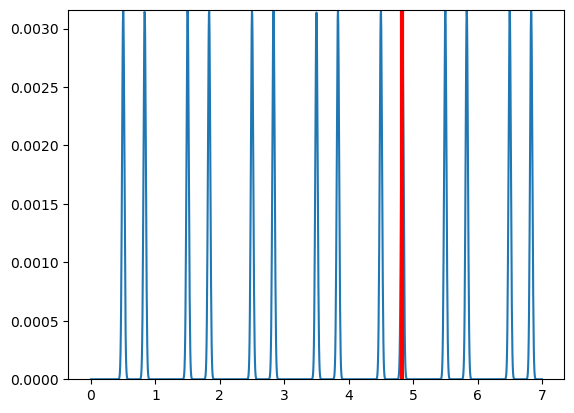

In [87]:
plt.plot(vE/omB, vD)
plt.vlines(mu/omB, ymin=0, ymax=np.amax(vD), color='red', linewidth=3)
plt.ylim(0,np.amax(vD))

In [88]:
set_num_threads(5)   # choose the number of threads
print(get_num_threads())  # verify

@njit(parallel=True, fastmath=True)  # fastmath optional but often helpful
def compute_avg_num_e(arr_mu, T, vx, vU, vD, vE, d):
    dx = abs(vx[0] - vx[1])   # use built-in abs, Numba handles it fine
    n_mu = arr_mu.size
    avg_num_e = np.empty(n_mu)   # allocate once

    for nmu in prange(n_mu):
        mu = arr_mu[nmu]
        num_e_free = number_e(T, vx, vU, vD, vE, mu)
        # use .sum() instead of np.sum() for slightly less overhead
        avg_num_e[nmu] = dx * num_e_free.sum() / (2.0 * d)

    return avg_num_e

@njit
def self_cons(T, d, vx, vD, vE, mu0, targ_num_e, kappa0, mK, vU, vUD, vUG, iterations):
    alpha = .00002
    dx = np.abs(vx[0]-vx[1])
    v_mu = np.zeros(iterations)
    v_num_e = np.zeros(iterations)
    mu = mu0
    for ni in range(iterations):
        
        arr_mu = mu + np.linspace(-.4,.4,200)*mu
        avg_num_e = compute_avg_num_e(arr_mu, T, vx, vU, vD, vE, d)
        nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
        mu = arr_mu[nmui]
        v_mu[ni] = mu
        v_num_e[ni] = avg_num_e[nmui]
        
        vnum_e = number_e(T, vx, vU, vD, vE, mu)


        vUnew = kappa0 * dx * np.dot(mK, vnum_e) + vUD + vUG
        
        vU = alpha*(vUnew) + (1-alpha)*vU
        vU = vU - np.amin(vU)
    
    return v_mu, v_num_e, vU, vnum_e

iterations = 8000
v_mu, v_num_e, vU, vnum_e = self_cons(T, d, vx, vD, vE, mu, targ_num_e, kappa0, mK, vU, vUD, vUG, iterations)

5


In [89]:
mu_print = v_mu[-1]   # value you want in metadata

header = f"""Data file for U(x)
mu = {mu_print}
omB = {omB}
Columns:
1) x
2) U(x)
"""

np.savetxt(
    "Ux.dat",
    np.column_stack([vx, vU]),
    header=header,
    fmt="%.8e",          # scientific format (change if you prefer)
    comments="# "
)

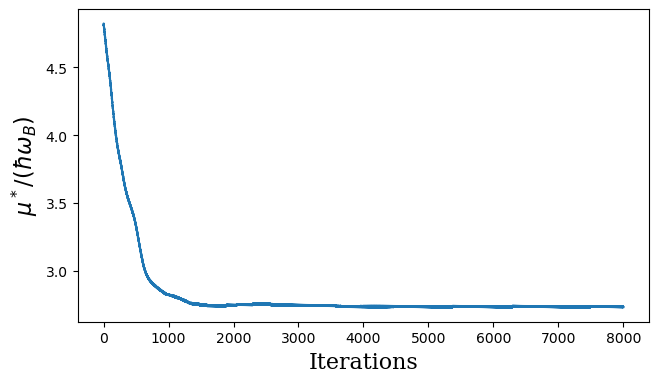

In [90]:
plt.plot(np.linspace(0,iterations, iterations), v_mu/omB)
plt.xlabel(r"Iterations", fontdict=font)
plt.ylabel(r"$\mu^*/(\hbar \omega_B)$", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("conv_mu.pdf")

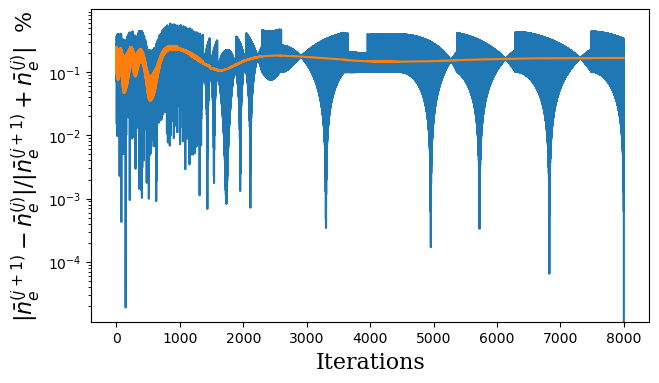

In [91]:
plt.plot(np.linspace(0,iterations, iterations), 100*np.abs(v_num_e/(v_num_e[-1])-1.) )
plt.plot(np.linspace(0,iterations-1, iterations-1), 100*np.abs( (v_num_e[1:iterations]-v_num_e[0:iterations-1])/(v_num_e[1:iterations]+v_num_e[0:iterations-1] )) )
plt.yscale('log')
plt.xlabel(r"Iterations", fontdict=font)
#plt.ylabel(r"$|\delta \bar{n}_e/\bar{n}_e - 1|$  %", fontdict=font)
plt.ylabel(r"$|\bar{n}_e^{(j+1)}-\bar{n}_e^{(j)}|/|\bar{n}_e^{(j+1)}+\bar{n}_e^{(j)}|$  %", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("conv_esti.pdf")

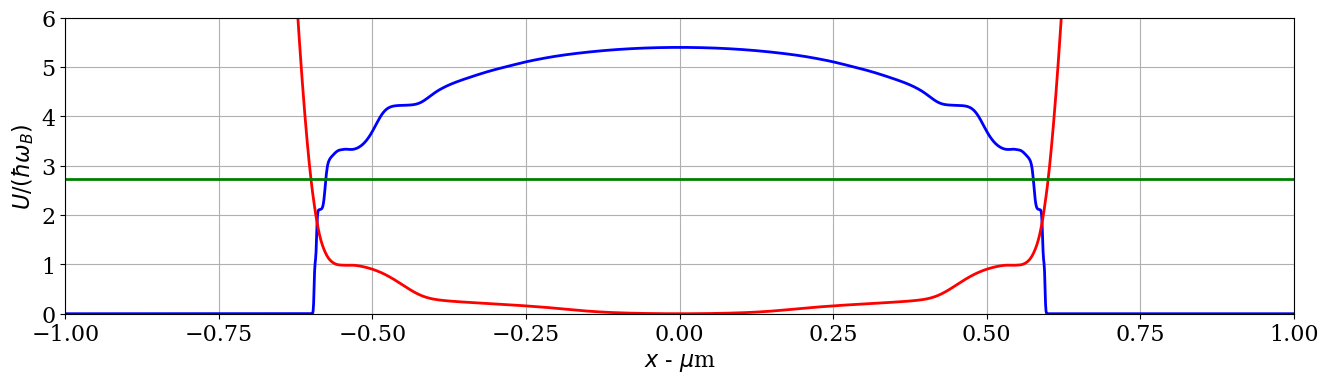

In [92]:
ymax = 6
plt.plot( vx*1e-3, vnum_e/np.amax(vnum_e)*ymax*9./10., color='blue', linewidth=2 )
#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx*1e-3, vU/omB , color='red', linewidth=2)
plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(0,ymax)
plt.xlim(-d*1e-3,d*1e-3)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 100 / 25.4)
plt.tight_layout()

#plt.savefig("eff_conf.pdf")

In [93]:
print(targ_num_e, np.sum(vnum_e)*dx/(2.*d))

0.004 0.00399590530746938


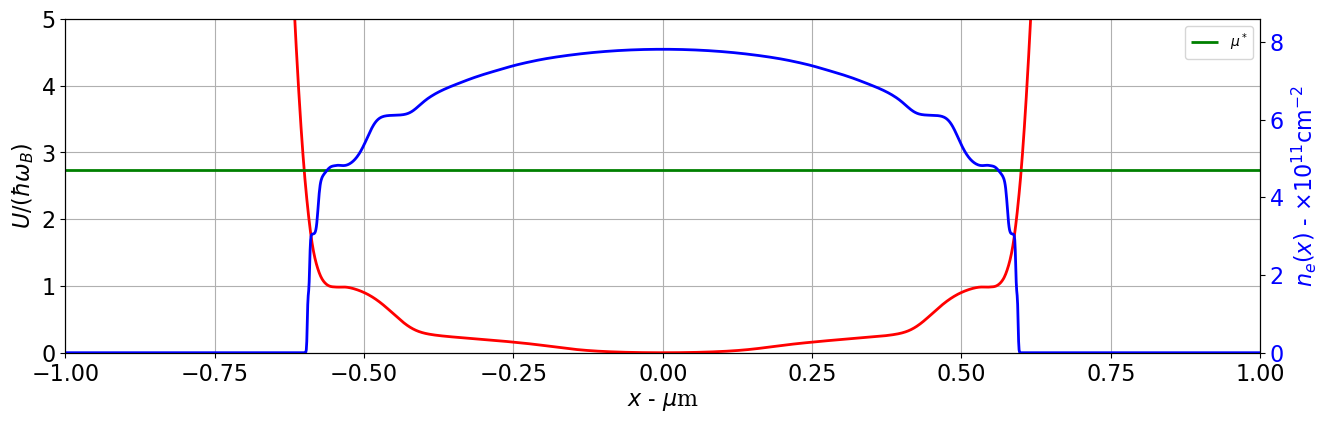

In [94]:
ymax = 5

fig, ax = plt.subplots()

# --- LEFT Y-AXIS (potential) ---
ax.plot(vx*1e-3, vU/omB, color='red', linewidth=2)
ax.hlines(v_mu[-1]/omB, xmin=-d*1e-3, xmax=d*1e-3,
          color='green', linewidth=2, label=r"$\mu^*$")

ax.set_ylim(0, ymax)
ax.set_xlim(-d*1e-3, d*1e-3)

# --- RIGHT Y-AXIS (blue curve) ---
ax2 = ax.twinx()
ax2.plot(
    vx*1e-3,
    vnum_e*1e3,
    color='blue',
    linewidth=2
)

ax2.set_ylim(0, np.amax(vnum_e*1e3)*1.1)   # same scale for visual alignment
ax2.tick_params(axis='y', labelcolor='blue')



ax.set_xlabel(r"$x$ - $\mu$m", fontdict=font)
ax.set_ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
ax2.set_ylabel(r"$n_e(x)$ - $\times 10^{11} {\rm cm}^{-2}$", fontdict=font, color='blue')

# --- Tick styling ---
ax.tick_params(axis='both',
               labelsize=font['size'],
               labelcolor=font['color'])
ax2.tick_params(axis='y',
                labelsize=font['size'],
                labelcolor='blue')

ax.grid()
ax.legend()

# --- Figure size ---
fig.set_size_inches(340 / 25.4, 110 / 25.4)
fig.tight_layout()

plt.savefig("U_CSG1.pdf")

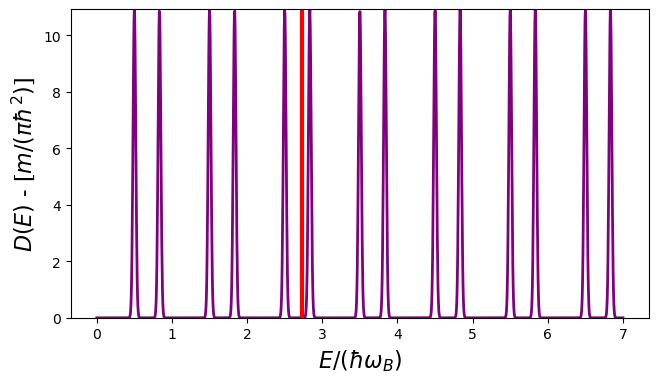

In [95]:
plt.plot(vE/omB, np.pi*lB**2*omB*vD, color='purple', linewidth=2)
plt.vlines(v_mu[-1]/omB, ymin=0, ymax=np.amax(np.pi*lB**2*omB*vD), color='red', linewidth=3)
plt.ylim(0,np.pi*lB**2*omB*np.amax(vD))

plt.xlabel(r"$E/(\hbar\omega_B)$", fontdict=font)
plt.ylabel(r"$D(E)$ - [$m/(\pi \hbar^2)$]", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("DOS_mu.pdf")

In [96]:
def ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    if T > .01:
        for ne, E in enumerate(vE):
            #dF = np.exp( (E + vU - mu)/T ) /( np.exp( (E + vU - mu)/T ) + 1. )**2./T 
            logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.
            dF = np.exp(logdFT)/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

dnum_e = ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu)


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_57641/2726045364.py:8: RuntimeWarning: overflow encountered in exp
  logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.


In [97]:
#vnum_e = number_e(T, vx, vU, vD, vE, mu)
#dnum_e = ddddmu_dnumber_e(T, vx, vU, vD, vE, mu)
dnum_e = ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu)


mK_1D = kernel_1D_image(vx, vt, d, 10000)

#dnum_e = number_e(T, vx, vU, vD, vE, mu)

matrix_inv = np.eye(len(vx)) +  kappa0 * dx * np.multiply(mK , dnum_e[np.newaxis, :])
MMmatrix = scipy.linalg.inv(matrix_inv)
#MMmatrix = np.eye(len(vx))



UH = -.1
dU = - UH * kappa0 * dx * np.dot(mK, np.multiply(vx/(2*d), dnum_e ) )

dU = np.matmul(MMmatrix, dU)

print(np.amax(np.abs(MMmatrix)))


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_57641/2726045364.py:8: RuntimeWarning: overflow encountered in exp
  logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.


132.17846994022364


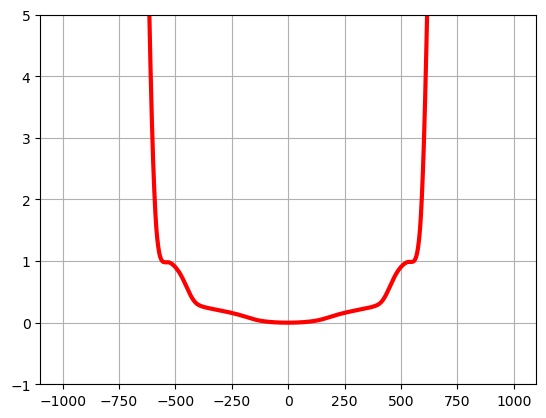

In [98]:
plt.ylim(-1,5)
#plt.xlim(-1500,1500)
plt.plot( vx, (vU+dU)/omB, color='red', linewidth=3 )

plt.grid()

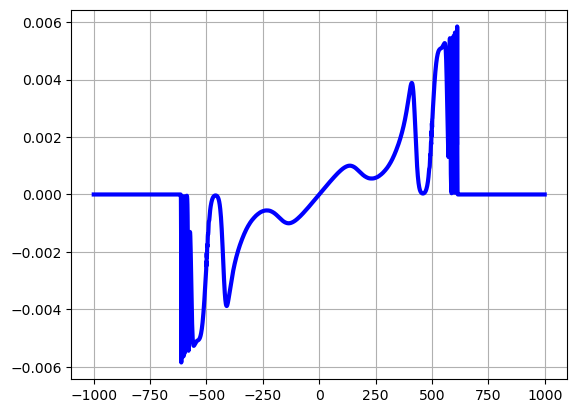

In [99]:
delta_num_e = np.multiply(dnum_e, - UH*vx/(2*d) + dU )

plt.plot( vx, delta_num_e/np.amax(vnum_e), color='blue', linewidth=3 )

#plt.xlim(-1500,1500)

plt.grid()

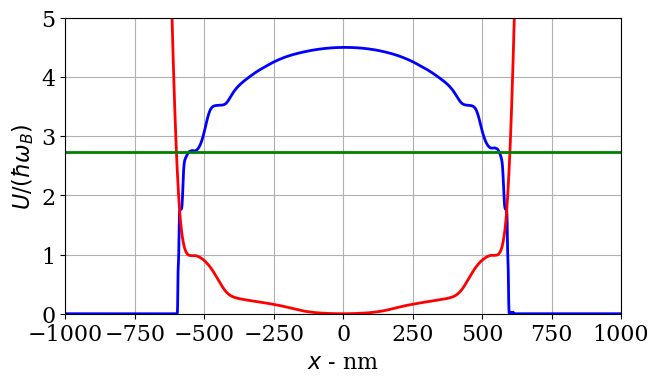

In [100]:
ymax = 5

tot_num_e = vnum_e + np.multiply(dnum_e, - UH*vx/(2*d) + dU )

plt.plot( vx, tot_num_e/np.amax(tot_num_e)*ymax*9./10., color='blue', linewidth=2 )
#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx, (vU+dU)/omB , color='red', linewidth=2)
plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(0,ymax)
plt.xlim(-d/1,d/1)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - nm", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("U_perturb1.pdf")

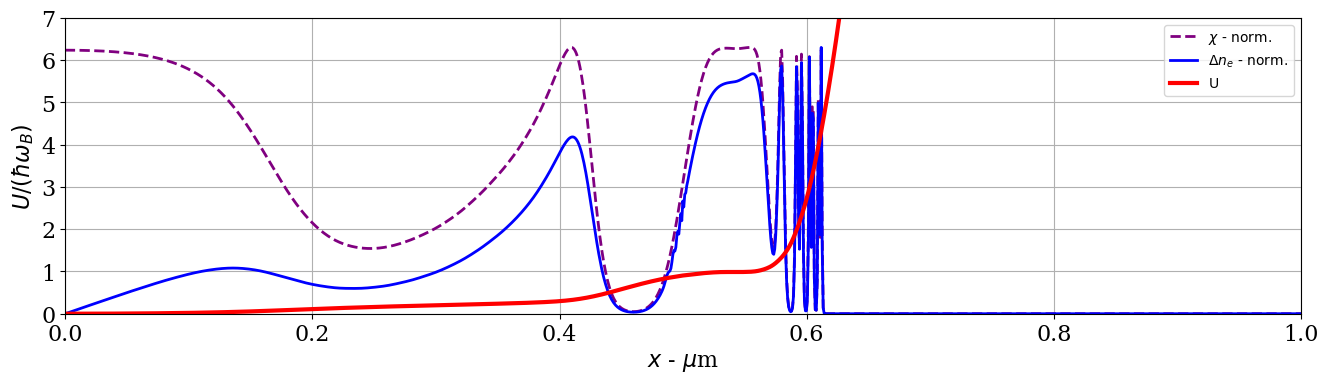

In [101]:
ymax = 7

tot_num_e = vnum_e - UH*np.multiply(vx/(2*d), dnum_e)

plt.plot( vx*1e-3, dnum_e/np.amax(dnum_e)*ymax*9./10., linestyle='--', color='purple', linewidth=2, label=r"$\chi$ - norm." )
plt.plot( vx*1e-3, delta_num_e/np.amax(delta_num_e)*ymax*9./10., color='blue', linewidth=2, label=r"$\Delta n_e$ - norm." )

#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx*1e-3, (vU+dU)/omB , color='red', linewidth=3, label=r"U")
#plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2, label=r"$\mu^*$")

plt.ylim(0,ymax)
#plt.xlim(0,d*1e-3)
plt.xlim(0,1)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()
plt.legend()

plt.gcf().set_size_inches(340 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("Uchin_zoom_perturb1.pdf")

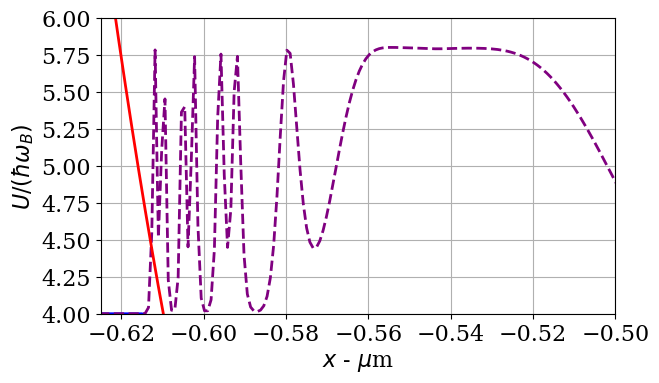

In [102]:
ymin = 4
ymax = 6

tot_num_e = vnum_e - UH*np.multiply(vx/(2*d), dnum_e)

plt.plot( vx*1e-3, delta_num_e/np.amax(delta_num_e)*ymax*9./10.+ymin, color='blue', linewidth=2 )
plt.plot( vx*1e-3, dnum_e/np.amax(dnum_e)*(ymax-ymin)*9./10.+ymin, linestyle='--', color='purple', linewidth=2 )

#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx*1e-3, (vU+dU)/omB , color='red', linewidth=2)
plt.hlines(v_mu[-1]/omB, xmin=-d*1e-3, xmax=d*1e-3, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(ymin,ymax)
plt.xlim(-d*1e-3/1.6,-d*1e-3/2)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()

In [103]:
print( np.sum(vnum_e)*dx, targ_num_e*2*d )

7.9918106149387595 8.0
